# 1. Setup
Bài thực hành sử dụng bộ data Titanic để dự đoán tỉ lệ sống sót của người trên tàu.

Authentication Kaggle:

In [111]:
# === Kaggle Auth via Google Drive ===
# One-time: upload kaggle.json to your Google Drive root, then paste this cell
import os, json

if not os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    !cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json

# Both legacy kaggle package and new kaggle SDK need the token
with open(os.path.expanduser('~/.kaggle/kaggle.json')) as f:
    creds = json.load(f)
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_' + creds['key']
print('Kaggle auth ready.')

Kaggle auth ready.


Download data:

In [112]:
from pathlib import Path

iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
if iskaggle: path = Path('../input/titanic')
else:
    path = Path('titanic')
    if not path.exists():
        import zipfile,kaggle
        kaggle.api.competition_download_cli(str(path))
        zipfile.ZipFile(f'{path}.zip').extractall(path)

Import thư viện và config:

In [113]:
import torch, numpy as np, pandas as pd
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

# 2. Cleaning the data
Vì data là dạng bảng (tabular data), nên ta sử dụng thư viện pandas để quan sát và xử lí.

## 2.1. Giới thiệu về Pandas

Pandas là thư viện chuyên xử lý data dạng bảng. Nó cung cấp object DataFrame - giống như 1 bảng excel và chứa dữ liệu, và cung cấp các hàm để thao tác lên dữ liệu.


In [114]:
# tạo object dataframe và đọc dữ liệu từ file train.csv
df = pd.read_csv(path/'train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Một số lệnh thao tác cơ bản trong pandas:

In [115]:
df.head()        # xem thử 5 hàng đầu của bảng (giống bạn scroll xem sơ qua Excel)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [116]:
df.describe()     # thống kê nhanh: count (tổng số, mean(trung bình), std(công sai/độ lệch chuẩn), min, max,... của các cột số

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [117]:
df['Age']         # lấy RIÊNG 1 cột (ở đây là cột tuổi) ra - kết quả là 1 "Series" (1 cột đơn)

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [118]:
df['Age'].isna()  # kiểm tra ô nào trong cột Age đang bị thiếu, False là có dữ liệu, True là NaN (không có dữ liệu)

,Age
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,True
889,False


## 2.1. Clean data
### 2.1.1. Empty/NaN cell
Linear model / Neural network hoạt động dựa trên việc nhân ma trận giữa giá trị và hệ số. Nhưng trong dữ liệu hiện tại đang có các cell không có dữ liệu như NaN, hoặc trống -> Khi thực hiện nhân sẽ báo lỗi. Vì thế chúng ta cần phải thay thế giá trị trống bằng giá trị phù hợp. 

Trước tiên, để xem có những cell nào trống dữ liệu:

In [119]:
df.isna().sum()
# isna() trả về True/False cho từng ô
# sum() sẽ cộng các giá trị True (True=1, False=0) để đếm số ô bị thiếu dữ liệu trong mỗi cột

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Có thể thấy Age có 177 cell trống, Cabin 687 cell trống và Embarked 2 cell trống.

Để thực hiện thay thế giá trị, chúng ta có nhiều cách tùy thuộc vào việc bị trống bao nhiêu cell trong cột, ví dụ:
* Age (177 giá trị thiếu): điền bằng median, mean hoặc dự đoán bằng mô hình.
* Embarked (2 giá trị thiếu): điền bằng giá trị xuất hiện nhiều nhất (mode).
* Cabin (687 giá trị thiếu): thường bỏ cột hoặc chỉ trích xuất thông tin đơn giản (ví dụ ký tự đầu của cabin như C, E, B) nếu thấy hữu ích, vì tỷ lệ thiếu quá lớn.

Trong bài thực hành này ta sẽ chọn cách nhanh nhất và đơn giản nhất là sử dụng mode:

In [120]:
modes = df.mode().iloc[0]
# .mode() trả về 1 dataframe chứa các giá trị mode (giá trị xuất hiện nhiều nhất) của từng cột
# .iloc[0] lấy hàng đầu tiên của dataframe mode (iloc = index location)
# vì có thể có nhiều giá trị mode cho 1 cột (ví dụ cột Sex có thể có cả 'male' và 'female' đều là mode nếu số lượng bằng nhau)   
modes

,0
PassengerId,1
Survived,0.0
Pclass,3.0
Name,"Abbing, Mr. Anthony"
Sex,male
Age,24.0
SibSp,0.0
Parch,0.0
Ticket,1601
Fare,8.05


Có thể thấy Mode của Age = 24, Cabin = "B96 B98" (1 giá trị, ko phải nhiều), Embarked = "S" 

Để fill các giá trị mode này vào cột, sử dụng:

In [121]:
# fillna() sẽ điền các ô bị thiếu dữ liệu (NaN) bằng giá trị mode của cột đó, 
# inplace=True nghĩa là thay đổi trực tiếp trên dataframe df, không tạo ra bản sao mới
df.fillna(modes, inplace=True)

Check lại sau khi thay đổi:

In [122]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [123]:
# .describe(include=(np.number)) sẽ thống kê nhanh các cột số, bao gồm cả các cột đã được điền dữ liệu NaN
df.describe(include=(np.number))

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2.1.2. Value distribution
Thông qua describe, ta có thể thấy mặc dù trung bình của Fare - giá vé chỉ 32$, nhưng max của nó là 512$, điều này là bình thường. Tuy nhiên nhưng cell có giá trị rất lớn so với các cell còn lại có thể gây ra mất cân đối phân phối. Cụ thể quan sát histogram sau.

(Histogram là một dạng biểu đồ hình cột dùng để thể hiện sự phân bố của một tập dữ liệu số liên tục. Cụ thể, trục ngang chia dữ liệu thành các khoảng giá trị (bins), còn trục dọc thể hiện tần suất hoặc số lần xuất hiện của các giá trị trong mỗi khoảng đó)

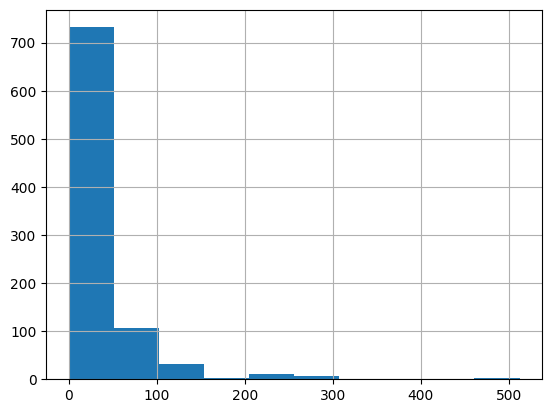

In [124]:
df['Fare'].hist();

Trục x = các khoảng giá trị = các khoảng tiền, trục y = tần suất -> số khách mua vé với giá đó. Có thể thấy số lượng mua vé 500$ rất ít. Và phân phối của chúng ta rất lệch (skewed) về 1 bên.

Neural network không yêu cầu dữ liệu phải có phân phối đều/hình chuông, nhưng dữ liệu có phân phối quá lệch (skewed) và nhiều outlier sẽ khiến:
* gradient bị chi phối bởi một số ít mẫu có giá trị rất lớn.
* các mẫu phổ biến (chiếm đa số) khó được học tốt.
* quá trình tối ưu kém ổn định và chậm hội tụ.

Để xử lý, một phương pháp phổ biến là xử dụng Logarith để nén các con số lớn lại và giúp phân phối hợp lí hơn.

Để lí giải về việc dùng Logarith. Tưởng tượng 2 cặp người:
* Người A lương 10 triệu/tháng, người B lương 11 triệu/tháng -> chênh nhau 1 triệu
* Người C lương 100 triệu/tháng, người D lương 101 triệu/tháng -> cũng chênh nhau 1 triệu

Về mặt con số tuyệt đối, 2 cặp này chênh lệch y hệt nhau (đều là 1 triệu). Nhưng trong thực tế A lên B là tăng 10% lương - khá đáng kể, sinh hoạt thoải mái hơn. C lên D là tăng 1% - gần như không khác gì.

Nếu ta đưa thẳng con số gốc (10tr, 11tr, 100tr, 101tr) vào model, model chỉ nhìn thấy "chênh lệch = 1 triệu" ở cả 2 cặp - nó không tự biết rằng cặp A-B thực ra "khác biệt" nhiều hơn hẳn cặp C-D. Model bị đánh lừa bởi con số tuyệt đối, trong khi cái thực sự có ý nghĩa là tỉ lệ phần trăm thay đổi.

Log xử lí bằng cách:
* log(11) - log(10) ≈ 0.095   →  tương ứng mức tăng ~10%
* log(101) - log(100) ≈ 0.010 →  tương ứng mức tăng ~1%

Giờ khoảng cách sau log (0.095 vs 0.010) đã phản ánh đúng mức độ khác biệt thật ngoài đời (10% vs 1%) - không còn bị đánh đồng là "chênh 1 triệu" như nhau nữa.

Đối với cột Fare trong dữ liệu Titanic, vé $5 với vé $10, tuy chỉ chênh $5, nhưng thực chất là gấp đôi giá, khả năng cao thuộc 2 hạng khách khác hẳn nhau. Ngược lại vé $495 với vé $500, cũng chênh $5, nhưng thực chất gần như giống hệt nhau (cùng hạng sang, chênh không đáng kể). Nếu dùng Fare gốc, model sẽ coi 2 cặp này "khác nhau như nhau" (đều chênh $5) - sai lệch với thực tế. Log giúp model "nhìn" đúng: cặp $5–$10 cách xa nhau, cặp $495–$500 gần sát nhau.

Tóm lại: Log transform biến "chênh lệch theo số tuyệt đối" thành "chênh lệch theo tỉ lệ %" - mà với giá cả/tiền bạc, tỉ lệ % mới là thứ có ý nghĩa thật, không phải con số trừ thẳng ra.

Để thực hiện chuyển đổi các giá trị bằng Log, thực hiện:

In [125]:
# np.log() sẽ tính logarit tự nhiên (base e) của từng giá trị trong cột Fare
# +1 để tránh log(0) gây lỗi
df['LogFare'] = np.log(df['Fare']+1)

Xem lại biểu đồ sau khi chuyển đổi:

<Axes: >

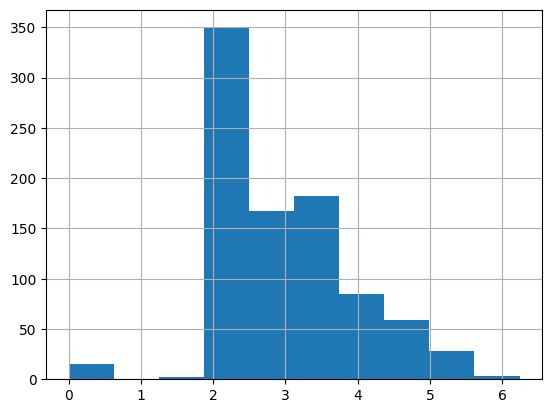

In [126]:
df['LogFare'].hist()

### 2.1.3. Convert categorical column

Như đã biết, mô hình chỉ chỉ có thể học các con số, không thể học trực tiếp văn bản, vì thế ta cần chuyển đổi các cột mang tính phân loại như Sex, Embarked, PClass (chỉ những cột tính phân loại và có ít các giá trị khác nhau).

In [127]:
#include=[object] sẽ thống kê nhanh các cột object (các cột dạng text, categorical)
df.describe(include=[object])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,B96 B98,S
freq,1,577,7,691,646


Có thể thấy Cột Sex có 2 giá trị text khác nhau và Embarked 3 giá trị khác nhau.

Nhưng cũng cần lưu ý cả cột Pclass, do ta lọc các cột dạng object, còn pclass trong data có dạng int64 nên không hiển thị, còn trong dữ liệu, pclasses có 3 giá trị khác nhau là 1 2 3 đại diện cho hạng của khoang/phòng -> người giàu/phổ thông.

In [128]:
pclasses = sorted(df.Pclass.unique())
pclasses

[np.int64(1), np.int64(2), np.int64(3)]

Để biến đổi các cột trên, ta cần thực hiện bằng Dummy-variables/One-hot coding, bằng cách tạo ra các cột mới tương ứng với các giá trị riêng biệt và đánh dấu 1 0 = true false.

In [129]:
cols = ["Sex","Pclass","Embarked"]
existing_cols = [c for c in cols if c in df.columns] 
if existing_cols: # tránh lỗi do chạy lại nhiều lần
    # get_dummies() sẽ tạo ra các cột giả (dummy columns) cho các giá trị categorical trong các cột Sex, Pclass
    df = pd.get_dummies(df, columns=existing_cols)
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'LogFare', 'Sex_female', 'Sex_male',
       'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [130]:
added_cols = ['Sex_male', 'Sex_female', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
df[added_cols].head() # xem thử các cột giả vừa được tạo ra từ các cột categorical

,Sex_male,Sex_female,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,True,False,False,False,True,False,False,True
1,False,True,True,False,False,True,False,False
2,False,True,False,False,True,False,False,True
3,False,True,True,False,False,False,False,True
4,True,False,False,False,True,False,False,True


In [131]:
df

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,LogFare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,B96 B98,2.110213,False,True,False,False,True,False,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",38.0,1,0,PC 17599,71.2833,C85,4.280593,True,False,True,False,False,True,False,False
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,2.188856,True,False,False,False,True,False,False,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,3.990834,True,False,True,False,False,False,False,True
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,B96 B98,2.202765,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,B96 B98,2.639057,False,True,False,True,False,False,False,True
887,888,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,3.433987,True,False,True,False,False,False,False,True
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",24.0,1,2,W./C. 6607,23.4500,B96 B98,3.196630,True,False,False,False,True,False,False,True
889,890,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,3.433987,False,True,True,False,False,True,False,False


Như vậy chúng ta đã hoàn tất clean data và có đủ Independent variable = Features / Input variables = thông tin đưa cho mô hình (Các cột như Age, sex, PClass, Fare,..) và Dependent varaible = Target/Label/Output = thông tin muốn mô hình dự đoán (Cột Survived). Để phục vụ việc tính toán model, chúng ta cần chuyển hết chúng sang định dạng tensor trước, chỉ là đổi từ dataframe sang tensor để tính đạo hàm, vẫn là dạng bảng.

Chuyển independent variable sang tensor:

In [132]:
from torch import tensor

t_dep = tensor(df.Survived)

Chuyển dependent variable sang tensor

In [133]:
indep_cols = ['Age', 'SibSp', 'Parch', 'LogFare'] + added_cols # các cột dữ liệu đầu vào (features) để dự đoán cột Survived, + added_cols là các cột giả vừa được tạo ra từ các cột categorical

t_indep = tensor(df[indep_cols].values.astype(float), dtype=torch.float)
t_indep

tensor([[22.0000,  1.0000,  0.0000,  2.1102,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [38.0000,  1.0000,  0.0000,  4.2806,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [26.0000,  0.0000,  0.0000,  2.1889,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  1.0000,  0.0000,  3.9908,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  0.0000,  0.0000,  2.2028,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [24.0000,  0.0000,  0.0000,  2.2469,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [54.0000,  0.0000,  0.0000,  3.9677,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        ...,
        [25.0000,  0.0000,  0.0000,  2.0857,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [39.0000,  0.0000,  5.0000,  3.4054

In [134]:
t_indep.shape

torch.Size([891, 12])

## 3. Setting up a linear model
Chúng ta sẽ bắt đầu xây dựng một linear model trước. Tưởng tượng bạn là nhà tuyển dụng, chấm điểm ứng viên bằng công thức: Điểm = (Kinh nghiệm × 3) + (Bằng cấp × 2) + (Phỏng vấn × 5). Mỗi tiêu chí nhân với 1 "hệ số quan trọng" (trọng số), rồi cộng tất cả lại ra 1 điểm tổng -> Đây chính là linear model. Áp dụng tr ong bài toán Titanic:

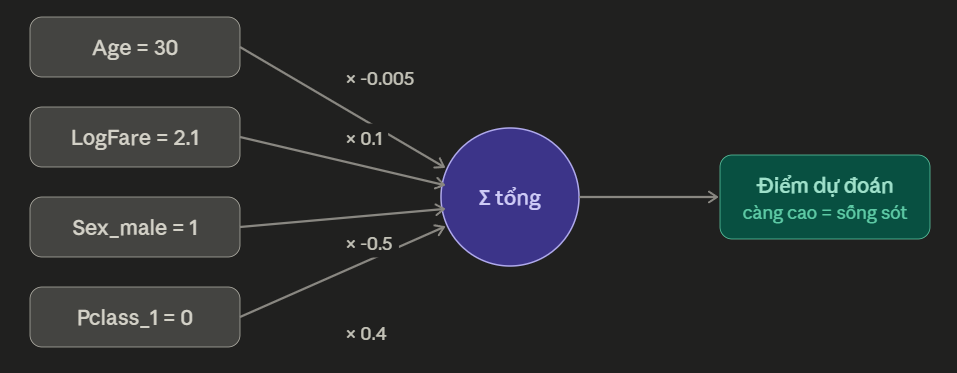

Mỗi cột Age, LogFare,.. có một hệ số riêng -0.005, 0.1,.. đây chính là coefficients - hệ số, hay còn gọi là weights.

Để khởi tạo hệ số, ta khởi tạo ngẫu nhiên qua Pytorch:

In [135]:
torch.manual_seed(442) # Cố định ngẫu nhiên để kết quả nhất quán

n_coeff = t_indep.shape[1] # số lượng hệ số (coefficients) cần học, bằng số cột dữ liệu đầu vào (features) của t_indep
coeffs = torch.rand(n_coeff)-0.5 # Khởi tạo ngẫu nhiên các hệ số (coefficients) ban đầu, giá trị trong khoảng [-0.5, 0.5)
coeffs 

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625])

Để tính toán dự đoán, chúng ta thực hiện nhân các hàng với hệ số và tính tổng.

In [136]:
t_indep*coeffs

tensor([[-10.1838,   0.1386,   0.0000,  -0.4772,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-17.5902,   0.1386,   0.0000,  -0.9681,  -0.0000,  -0.3147,   0.4876,   0.0000,   0.0000,  -0.4392,   0.0000,   0.0000],
        [-12.0354,   0.0000,   0.0000,  -0.4950,  -0.0000,  -0.3147,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-16.2015,   0.1386,   0.0000,  -0.9025,  -0.0000,  -0.3147,   0.4876,   0.0000,   0.0000,  -0.0000,   0.0000,   0.3625],
        [-16.2015,   0.0000,   0.0000,  -0.4982,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-11.1096,   0.0000,   0.0000,  -0.5081,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.2103,   0.0000],
        [-24.9966,   0.0000,   0.0000,  -0.8973,  -0.2632,  -0.0000,   0.4876,   0.0000,   0.0000,  -0.0000,   0.0000,   0.3625],
        ...,
        [-11.5725,   0.0000,   0.0000,  -0.4717,  -0.2632,  -0.0000,   0.0000

Tuy nhiên có thể thấy rằng giá trị của cột 1 - Age đang áp đảo so với giá trị các cột khác, bởi vì Age giao động từ 0-80 trong khi male chỉ cóp 0 hoặc 1. Vì thế ta cần chuẩn hóa lại, bằng cách chia mỗi cột cho max của nó -> Mọi cột đều chỉ nằm trong khoảng 0-1.

In [137]:
vals,indices = t_indep.max(dim=0) # tính giá trị lới nhất (max) của từng cột trong t_indep, trả về 2 tensor: vals là giá trị max, indices là chỉ số (index) của giá trị max trong từng cột
t_indep = t_indep / vals # chia từng cột trong t_indep cho giá trị max tương ứng
t_indep

tensor([[0.2750, 0.1250, 0.0000, 0.3381, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4750, 0.1250, 0.0000, 0.6859, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
        [0.3250, 0.0000, 0.0000, 0.3507, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4375, 0.1250, 0.0000, 0.6395, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.4375, 0.0000, 0.0000, 0.3530, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.3000, 0.0000, 0.0000, 0.3600, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000],
        [0.6750, 0.0000, 0.0000, 0.6358, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        ...,
        [0.3125, 0.0000, 0.0000, 0.3342, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.4875, 0.0000, 0.8333, 0.5456, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000],
        [0.3375, 0.0000, 0.0000, 

In [138]:
t_indep*coeffs

tensor([[-0.1273,  0.0173,  0.0000, -0.0765, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2199,  0.0173,  0.0000, -0.1551, -0.0000, -0.3147,  0.4876,  0.0000,  0.0000, -0.4392,  0.0000,  0.0000],
        [-0.1504,  0.0000,  0.0000, -0.0793, -0.0000, -0.3147,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2025,  0.0173,  0.0000, -0.1446, -0.0000, -0.3147,  0.4876,  0.0000,  0.0000, -0.0000,  0.0000,  0.3625],
        [-0.2025,  0.0000,  0.0000, -0.0798, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.1389,  0.0000,  0.0000, -0.0814, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.2103,  0.0000],
        [-0.3125,  0.0000,  0.0000, -0.1438, -0.2632, -0.0000,  0.4876,  0.0000,  0.0000, -0.0000,  0.0000,  0.3625],
        ...,
        [-0.1447,  0.0000,  0.0000, -0.0756, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2257,  0.0000,  0.2008, -0.1234

Tính predictions:

In [139]:
# .sum(axis=1) sẽ tính tổng các giá trị trong mỗi hàng (row) của tensor, kết quả là 1 tensor 1 chiều có cùng số lượng hàng với t_indep 
preds = (t_indep*coeffs).sum(axis=1) 
preds

tensor([ 0.1927, -0.6239,  0.0979,  0.2056,  0.0968,  0.0066,  0.1306,  0.3476,  0.1613, -0.6285,  0.2579,  0.0796,  0.1836,  0.2457,
         0.1676, -0.0595,  0.2014,  0.1783,  0.0589, -0.6892,  0.0909,  0.1205,  0.0089,  0.2945,  0.2614,  0.1999, -0.6378,  0.4071,
        -0.0425,  0.1611, -0.5679, -0.5688, -0.0420, -0.0576, -0.5197,  0.2173, -0.6378,  0.1778,  0.1515, -0.6284,  0.0284,  0.1104,
        -0.6406, -0.4960, -0.0136,  0.1605,  0.0038, -0.0420, -0.6399,  0.1345,  0.3138,  0.1788, -0.6902,  0.0915, -0.7009,  0.3176,
         0.1514, -0.6638,  0.3084,  0.3422, -0.6262,  0.1563,  0.1831,  0.3664, -0.4753, -0.6049,  0.1051,  0.1890,  0.2996,  0.1812,
         0.1392,  0.2618,  0.1351, -0.6549,  0.0472,  0.1563,  0.1611,  0.1605,  0.3651,  0.0598,  0.1684,  0.1261, -0.0422,  0.2845,
         0.1745,  0.0864,  0.2951,  0.1605,  0.3325,  0.1605,  0.1315,  0.1844,  0.1884,  0.2150, -0.0387,  0.1605, -0.7551, -0.4586,
         0.0896,  0.1140,  0.0865,  0.1611,  0.3475,  0.1060, 

Như vậy chúng ta có 1 điểm bắt đầu để thực hiện quá trình Gradient descent.

Nhắc lại quy trình cũ, để thực hiện train model, ta trải qua 4 bước vòng lặp: Tính prediction -> Tính loss -> Tính gradient (loss.backward()) -> Cập nhật hệ số. Quy trình này được lặp lại dựa trên số lượng epoch.

Vì thế trước khi thực hiện gradient descent, ta cần setup loss function trước, ta sử dụng MAE - Mean Absolute Error:

In [140]:
loss = torch.abs(preds-t_dep).mean() # MAE = tính |dự đoán - thực tế| của tất cả các hàng, sau đó lấy trung bình. 
loss

tensor(0.5382)

Để thuận lợi hơn cho training loop, ta đưa tính pred và loss sang function:

In [141]:
def calc_preds(coeffs, indeps): return (indeps*coeffs.reshape(-1)).sum(axis=1)
def calc_loss(coeffs, indeps, deps): return torch.abs(calc_preds(coeffs, indeps)-deps).mean()

## 4. A Gradient descent step

Mỗi một bước gradient descent nhằm giảm loss xuống, giống như đi xuống dốc.

Để tính đạo hàm, ta sử dụng `requires_grad_()` của pytorch:

In [142]:
coeffs.requires_grad_()

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625], requires_grad=True)

In [143]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss

tensor(0.5382, grad_fn=<MeanBackward0>)

In [144]:
loss.backward()

In [145]:
# sau khi tính gradient, cần ngưng gradient để tránh việc cập nhật hệ số (coeffs) bị ảnh hưởng bởi gradient của các bước sau
with torch.no_grad():
    # cập nhật hệ số (coeffs) bằng cách trừ đi gradient nhân với learning rate (ở đây là 0.1)
    coeffs.sub_(coeffs.grad * 0.1)
    # xóa gradient để chuẩn bị cho bước tính gradient tiếp theo, tránh cộng dồn
    coeffs.grad.zero_() 
    print(calc_loss(coeffs, t_indep, t_dep))

tensor(0.5197)


## 5. Training the linear model

Để thực hiện train model, chúng ta cần phải chia data set thành các phần:
* training set
* validation set

In [146]:
from fastai.data.transforms import RandomSplitter
# dùng random splitter của fastai
# chia ra thành 2 array gồm các index random, do chúng ta không truyền vào dữ liệu, nên RandomSplitter sẽ tự động lấy số lượng hàng của df để chia
trn_split,val_split=RandomSplitter(seed=42)(df) 

In [147]:
# mapping index ra data
# training set và validation set của indep và dep variables
trn_indep,val_indep = t_indep[trn_split],t_indep[val_split] 
trn_dep,val_dep = t_dep[trn_split],t_dep[val_split]
len(trn_indep),len(val_indep)

(713, 178)

Ta sẽ chuyển đổi phần code update hệ số trước đó thành 1 function:

In [148]:
def update_coeffs(coeffs, lr):
    coeffs.sub_(coeffs.grad * lr)
    coeffs.grad.zero_()

Và một training loop thành function:

In [149]:
def one_epoch(coeffs, lr):
    loss = calc_loss(coeffs, trn_indep, trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"{loss:.3f}", end="; ")

Hàm khởi tạo hệ số ban đầu:

In [150]:
def init_coeffs(): return (torch.rand(n_coeff)-0.5).requires_grad_()

Và cuối cùng hàm để train một model

In [151]:
def train_model(epochs=30, lr=0.01):
    torch.manual_seed(442)
    coeffs = init_coeffs()
    # chạy training loop dựa trên số lượng epoch
    # 1 epoch = lặp qua toàn bộ dữ liệu, ta muốn epoch bao nhiêu tùy ý, epoch càng nhiều thì mô hình càng học tốt hơn, nhưng cũng dễ bị overfit (quá khớp) với dữ liệu training
    for i in range(epochs): one_epoch(coeffs, lr=lr)
    return coeffs

In [152]:
coeffs = train_model(18, lr=0.2)

0.536; 0.502; 0.477; 0.454; 0.431; 0.409; 0.388; 0.367; 0.349; 0.336; 0.330; 0.326; 0.329; 0.304; 0.314; 0.296; 0.300; 0.289; 

Như vậy ta có được các weights sau 18 lượt train.

In [153]:
def show_coeffs(): return dict(zip(indep_cols, coeffs.requires_grad_(False)))
show_coeffs()

{'Age': tensor(-0.2694),
 'SibSp': tensor(0.0901),
 'Parch': tensor(0.2359),
 'LogFare': tensor(0.0280),
 'Sex_male': tensor(-0.3990),
 'Sex_female': tensor(0.2345),
 'Pclass_1': tensor(0.7232),
 'Pclass_2': tensor(0.4112),
 'Pclass_3': tensor(0.3601),
 'Embarked_C': tensor(0.0955),
 'Embarked_Q': tensor(0.2395),
 'Embarked_S': tensor(0.2122)}

Và tính thử predictions:

In [154]:
preds = calc_preds(coeffs, val_indep)
preds

tensor([ 0.8160,  0.1295, -0.0148,  0.1831,  0.1520,  0.1350,  0.7279,  0.7754,  0.3222,  0.6740,  0.0753,  0.0389,  0.2216,  0.7631,
         0.0678,  0.3997,  0.3324,  0.8278,  0.1078,  0.7126,  0.1023,  0.3627,  0.9937,  0.8050,  0.1153,  0.1455,  0.8652,  0.3425,
         0.1262,  0.7630,  0.8877,  0.9052,  0.1191,  0.0804,  0.7958,  0.9393,  0.3941,  0.9915,  0.1023,  0.7437,  0.1713,  0.1023,
         0.1949,  0.9650,  0.1158,  0.8820,  0.1039,  0.1551,  0.1290,  0.7422,  0.4583,  0.2953,  0.2823,  0.0984,  0.1477,  0.1275,
         0.1295,  0.0759,  0.1124,  0.0900,  0.3338,  0.1366,  0.2824,  0.1124,  0.7358,  0.5246,  0.1554,  0.0564,  0.1290,  0.7183,
         0.0955,  0.7004,  0.1309,  0.1030,  0.4703,  0.1291,  0.1023,  0.4399,  0.1722,  0.0785,  0.2994,  1.1087,  0.1056,  0.1019,
         0.7005,  0.1302,  0.3914,  1.2342,  0.6726,  0.1587,  0.0755,  0.1023,  0.9732, -0.0350,  0.7629, -0.0018,  0.0842,  0.7901,
         0.7697,  0.1458,  0.1730,  0.7630,  0.0753,  0.0821, 

## 6. Measuring Accuracy

Nhìn vào coeffs sau khi train, ta thấy hệ số của Age và Sex_male mang giá trị âm. Vì các cột này đều >= 0 (đã chuẩn hóa/dummy hóa), hệ số âm nhân với input dương sẽ kéo điểm dự đoán xuống thấp - nghĩa là tuổi càng cao hoặc là nam giới thì khả năng sống sót dự đoán càng thấp, khớp với thực tế lịch sử ("phụ nữ và trẻ em được ưu tiên"). Tuy nhiên nhãn thật Survived chỉ có 0/1, nên cần quy đổi: quy ước preds > 0.5 -> coi là dự đoán sống sót, ngược lại -> dự đoán không sống sót.

In [155]:
# so sánh giữa tập dữ liệu thực tế (val_dep) và tập dữ liệu dự đoán (preds>0.5), ta sẽ xem thử tỉ lệ dự đoán đúng
results = val_dep.bool()==(preds>0.5)
results

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True, False, False, False,  True,  True, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True, False,  True,  True,  True, False,  True,  True,
         True, False, False,  True,  True,  True,  True, False, False,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True, False,  True, False, False,  True,  True,  True,  True,  True, False,  True,  True,  True,  True,
         True, False,  True,  True, False,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True, False, False, False,  True, False,  True,  True, False, False,  True,
         True,  True, False,  True,  True,  True,  True, False,  True,  True,  True,  True, False,  True,  True,  True,  True,  True,  True,
         True

True cho thấy ta dự đoán đúng và False là sai. Để xem trung bình tỉ lệ dự đoán đúng của chúng ta:

In [156]:
results.float().mean()

tensor(0.7865)

Như vậy sau 18 lần train, mô hình dự đoán đúng với tỉ lệ trung bình 78.65%.

Đưa quy trình tính accuracy thành function:

In [157]:
def acc(coeffs): return (val_dep.bool()==(calc_preds(coeffs, val_indep)>0.5)).float().mean()
acc(coeffs)

tensor(0.7865)

## 7. Using Sigmoid

Khi xem lại kết quả prediction, ta thấy có 1 vấn đề rằng tỉ lệ sống sot trước đó tính ra còn > 1 hoặc < 0.

In [158]:
preds

tensor([ 0.8160,  0.1295, -0.0148,  0.1831,  0.1520,  0.1350,  0.7279,  0.7754,  0.3222,  0.6740,  0.0753,  0.0389,  0.2216,  0.7631,
         0.0678,  0.3997,  0.3324,  0.8278,  0.1078,  0.7126,  0.1023,  0.3627,  0.9937,  0.8050,  0.1153,  0.1455,  0.8652,  0.3425,
         0.1262,  0.7630,  0.8877,  0.9052,  0.1191,  0.0804,  0.7958,  0.9393,  0.3941,  0.9915,  0.1023,  0.7437,  0.1713,  0.1023,
         0.1949,  0.9650,  0.1158,  0.8820,  0.1039,  0.1551,  0.1290,  0.7422,  0.4583,  0.2953,  0.2823,  0.0984,  0.1477,  0.1275,
         0.1295,  0.0759,  0.1124,  0.0900,  0.3338,  0.1366,  0.2824,  0.1124,  0.7358,  0.5246,  0.1554,  0.0564,  0.1290,  0.7183,
         0.0955,  0.7004,  0.1309,  0.1030,  0.4703,  0.1291,  0.1023,  0.4399,  0.1722,  0.0785,  0.2994,  1.1087,  0.1056,  0.1019,
         0.7005,  0.1302,  0.3914,  1.2342,  0.6726,  0.1587,  0.0755,  0.1023,  0.9732, -0.0350,  0.7629, -0.0018,  0.0842,  0.7901,
         0.7697,  0.1458,  0.1730,  0.7630,  0.0753,  0.0821, 

Để xử lý vấn đề này, ta sẽ cần chuyển hóa kết quả thông qua hàm Sigmoid, để ép chúng chỉ nằm trong giá trị 0->1. Giá trị dương càng lớn -> tiến tới 1, còn âm càng nhỏ thì tiến tới 0.

sigmoid(x) = 1 / (1 + e^(-x))

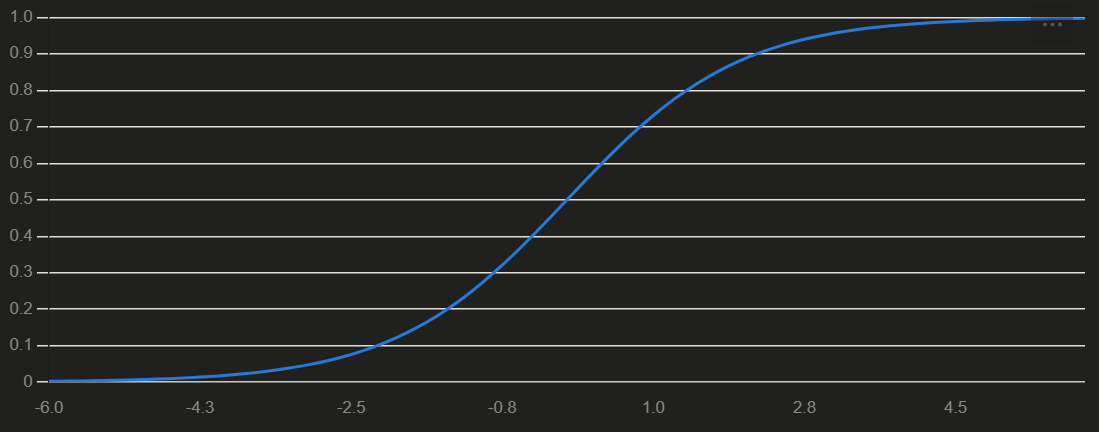

Pytorch cũng cung cấp sẵn hàm Sigmoid, ta chỉ cần sửa vào hàm calc_preds() trước đó:

In [159]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps*coeffs.reshape(-1)).sum(axis=1))
# .reshape(-1) để đảm bảo coeffs luôn là 1D, tương thích với cả init_coeffs() cũ (n_coeff,) và mới (n_coeff, 1)

Và bây giờ ta thử train lại model:

In [160]:
coeffs = train_model(lr=100)
# ở đây, lr đã tăng lên 100, vì hàm sigmoid sẽ làm cho các giá trị dự đoán gần 0 hoặc 1 hơn, gradient step bị co nhỏ lại và 1 bước sẽ rất ngắn,
# nên cần learning rate lớn hơn để cập nhật hệ số nhanh hơn
# có thể thử bỏ lr hoặc thay đổi để xem sự khác biệt khi tính accuracy


0.510; 0.327; 0.294; 0.207; 0.201; 0.199; 0.198; 0.197; 0.196; 0.196; 0.196; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 

In [161]:
acc(coeffs)

tensor(0.8258)

In [162]:
show_coeffs()

{'Age': tensor(-1.5061),
 'SibSp': tensor(-1.1575),
 'Parch': tensor(-0.4267),
 'LogFare': tensor(0.2543),
 'Sex_male': tensor(-10.3320),
 'Sex_female': tensor(8.4185),
 'Pclass_1': tensor(3.8389),
 'Pclass_2': tensor(2.1398),
 'Pclass_3': tensor(-6.2331),
 'Embarked_C': tensor(1.4771),
 'Embarked_Q': tensor(2.1168),
 'Embarked_S': tensor(-4.7958)}

## 8. Validate and submit

Ta sẽ cho model thử dự đoán trên test set:

In [163]:
tst_df = pd.read_csv(path/'test.csv')
tst_df  

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


Vì test set cũng cần xử lý dữ liệu như training set, nên cần điền các ô bị thiếu dữ liệu (NaN) bằng giá trị mode của cột đó, và tạo ra các cột giả (dummy columns) cho các giá trị categorical trong.

In [164]:
# Xử lý test set giống training set
tst_df.fillna(modes, inplace=True)

cols = ["Sex","Pclass","Embarked"]
existing_cols = [c for c in cols if c in tst_df.columns]
if existing_cols:
    tst_df = pd.get_dummies(tst_df, columns=existing_cols)

tst_df['LogFare'] = np.log(tst_df['Fare']+1)

tst_indep = tensor(tst_df[indep_cols].values.astype(float), dtype=torch.float)
tst_indep = tst_indep / vals

Tính prediction trên tập test:

In [165]:
tst_df['Survived'] = (calc_preds(coeffs, tst_indep)>0.5).int()

In [166]:
# thay kết quả predicted Survived vào cột Survived của test set, rồi xuất ra file sub.csv để submit lên Kaggle
sub_df = tst_df[['PassengerId','Survived']]
sub_df.to_csv('sub.csv', index=False)

In [167]:
!head sub.csv

PassengerId,Survived
892,0
893,0
894,0
895,0
896,0
897,0
898,1
899,0
900,1


Như vậy ta đã hoàn thành quy trình clean data - training - submit.

## 9. Using matrix production

Pytorch có cung cấp cho chúng ta toán tử `@`, về cơ bản thì nó vẫn chỉ là phép nhân ma trận trước đó, nhưng cú pháp gọn hơn và được Pytorch tối ưu rất mạnh trên GPU:

In [168]:
def calc_preds(coeffs, indeps): return torch.sigmoid(indeps@coeffs) # thay vì (indeps*coeffs).sum(axis=1)

Trong phần tới ta sẽ thực hiện việc xây dựng Neural network, cần phải nhân các ma trận với nhau. Mà phép nhân ma trận yêu cầu hình dạng chúng phải khớp theo quy tắc chặt chẽ (số cột ma trận nhân trước = số hàng ma trận sau). Vì thế ta cũng cần điều chỉnh lại shape của ma trận coeffs trước đó:

In [169]:
# TRƯỚC:
# def init_coeffs(): return (torch.rand(n_coeff)-0.5)

# SAU:
def init_coeffs(): return (torch.rand(n_coeff, 1)*0.1).requires_grad_()

Và cả trn_dep và val_dep cũng vậy:

In [170]:
if trn_dep.ndim == 1: trn_dep = trn_dep[:,None]
# sử dụng None để thêm 1 chiều mới vào tensor trn_dep, biến nó từ 1D thành 2D (cột vector) để phù hợp với việc nhân ma trận trong hàm calc_preds
if val_dep.ndim == 1: val_dep = val_dep[:,None]

Thử train lại model:

In [171]:
coeffs = train_model(lr=100)

0.512; 0.323; 0.290; 0.205; 0.200; 0.198; 0.197; 0.197; 0.196; 0.196; 0.196; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 

In [172]:
acc(coeffs)

tensor(0.8258)

## 10. A neural network - Add one hidden layer
Một linear model chỉ có thể tính được 1 công thức nhân-cộng duy nhất cho mọi hành khách. Nhưng thực tế, tỉ lệ sống sót có thể phụ thuộc vào sự kết hợp của nhiều yếu tố cùng lúc (ví dụ: "nữ và hạng sang" thì khả năng sống rất cao, nhưng "nữ nhưng hạng thấp và nhiều người thân đi cùng" thì lại khác), và 1 phép nhân cộng đơn giản không thể diễn đạt được các quan hệ nếu thì chồng chéo như vậy.

Vì thế, chúng ta cần sử dụng nhiều công thức nhân cộng nhỏ song song - tương ứng 1 neuron node, rồi gộp lại thành kết quả, đó chính là bản chất của neural network.

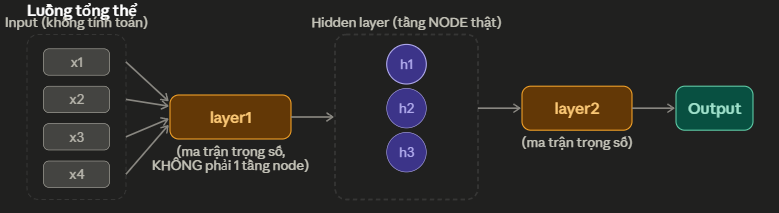

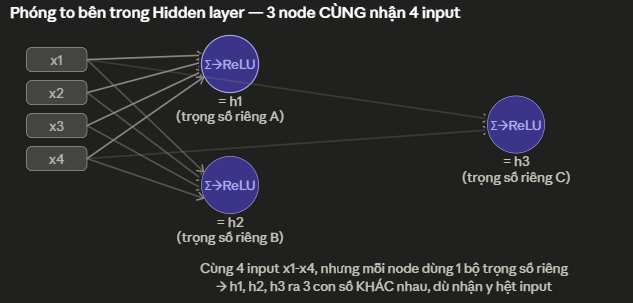

* Lưu ý dễ nhầm lẫn:
    * Layer = Các tầng neuron: Input layer, Hidden layer, Output layer.
    * Weight matrix - Ma trận trọng số: Nằm giữa 2 tầng neuron ví dụ Input -> W1 -> Hidden layer -> W2 -> Output

* h1, h2 là các node/neuron thuộc hidden layer, là đơn vị tính toán nhỏ nhất, thực hiện công việc:
    * Nhận nhiều input, nhân mỗi input với hệ số riêng tương ứng và cộng lại (tính linear - tuyến tính).
    * Đẩy kết quả vào Activation function:
        * Activation function là hàm phi tuyến để biến đổi kết quả, mỗi một hidden layer network đều cần có một activation function. Ví dụ ReLU, sử dụng trong hidden layer trước khi đưa sang layer 2. Khi sang deep learning ta sẽ ro hơn việc này.
        * Activation function là bắt buộc cho 1 hidden layer, vì nếu không có, thì khi chúng ta sử dụng nhiều hidden layer (như trong deep learning), các layer sẽ bị gộp vào nhau (vì không có bước biến đổi ở giữa nên bản chất chỉ là nhân với nhau). Mỗi activation function giống như bẻ ra các khúc gãy, và ghép các nhiều đoạn gãy với nhau thì càng ra đường cong phức tạp để mô tả đúng hình dạng dữ liệu thật -> Chính là bản chất của ReLu.

* Công thức của mỗi neuron:
    * Output = Activation(Input × Weight + Bias)

Bias là một hằng số được cộng thêm vào kết quả của neuron, giống như 1 điểm cố định để tránh kết quả khi tính bị rơi vào 0 (ảnh hưởng ReLu,..)

Mỗi 1 input sẽ được đưa vào các node các nhau với các hệ số riêng khác nhau, hệ số đó sẽ thể hiện mức độ quan trọng của input, ví dụ:
* h1 có thể "học được" tổ hợp kiểu: "chú trọng Sex_male + Pclass_1, ít quan tâm Age"
* h2 có thể học tổ hợp khác: "chú trọng Age + LogFare"
* h3 học 1 tổ hợp khác nữa

-> Mỗi node neuron đảm nhiệm phát hiện 1 kiểu quan hệ khác nhau trong dữ liệu. Đây chính là cách model quan sát được các quan hệ phức tạp mà 1 công thức đơn không làm được.

Để khởi tạo hệ số cho neural network:

In [ ]:
def init_coeffs(n_hidden=20):
    weight1 = (torch.rand(n_coeff, n_hidden)-0.5)/n_hidden # weight giữa input và hidden layer
    weight2 = torch.rand(n_hidden, 1)-0.3 # weight giữa hidden layer và output layer
    bias = torch.rand(1)[0] # bias giữa hidden layer và output layer

    return (
        weight1.requires_grad_(),
        weight2.requires_grad_(),
        bias.requires_grad_()
    )

Xây dựng neural network:

In [177]:
import torch.nn.functional as F 

def calc_preds(coeffs, indeps):
    # unpack các hệ số (coefficients) thành 3 phần: 
    # l1 là weight giữa input và hidden layer, 
    # l2 là weight giữa hidden layer và output layer, 
    # const là bias giữa hidden layer và output layer
    l1,l2,const = coeffs 
    # kết quả sau khi đi qua hidden layer với activation function ReLU,
    res = F.relu(indeps@l1)
    # kết quả sau khi đi qua output layer với bias
    res = res@l2 + const
    # sau khi đi qua output layer, ta áp dụng activation function sigmoid để đưa giá trị dự đoán về khoảng [0,1], phù hợp với bài toán phân loại nhị phân (binary classification)
    return torch.sigmoid(res)

In [ ]:
# hàm cập nhật các hệ số (coefficients) dựa trên gradient và learning rate, vì các hệ số bây giờ là 1 tuple gồm nhiều tensor, nên cần lặp qua từng tensor để cập nhật
def update_coeffs(coeffs, lr): 
    for layer in coeffs:
        layer.sub_(layer.grad * lr)
        layer.grad.zero_()

Train model:

In [178]:
coeffs = train_model(lr=1.4)

0.543; 0.532; 0.520; 0.505; 0.487; 0.466; 0.439; 0.407; 0.373; 0.343; 0.319; 0.301; 0.286; 0.274; 0.264; 0.256; 0.250; 0.245; 0.240; 0.237; 0.234; 0.231; 0.229; 0.227; 0.226; 0.224; 0.223; 0.222; 0.221; 0.220; 

In [179]:
coeffs = train_model(lr=20)

0.543; 0.400; 0.260; 0.390; 0.221; 0.211; 0.197; 0.195; 0.193; 0.193; 0.193; 0.193; 0.193; 0.193; 0.193; 0.193; 0.193; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 

In [180]:
acc(coeffs)

tensor(0.8258)

Có thể thấy dù chúng ta đã dùng Neural network, nhưng dự đoán thì tỉ lệ vẫn ngang với linear model, bởi vì bộ data set rất nhỏ và đơn giản, nên neural network không tạo ra lợi thế gì thêm trong trường hợp này.

## 11. Deep learning
Deep learning về cơ bản chỉ là neural network nhưng nhiều hidden layer hơn.

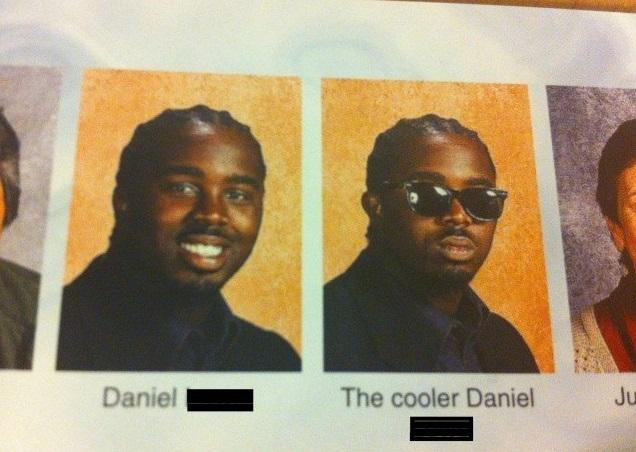

Input
   │
Hidden 1
   │
Hidden 2
   │
Hidden 3
   │
...
   │
Output

Quay lại các chương đầu trong computer vision, ta có thể thấy ứng dụng deeplearning để mỗi hidden layer học 1 feature khác nhau, ví dụ layer 1 học cạnh vật thể, layer 2 học góc, đường cong, layer 3 học mắt, tai, layer 4 học khuôn mặt,...

Khởi tạo hệ số:

In [ ]:
def init_coeffs():
    hiddens = [10, 10]  # kích thước của mỗi hidden layer
    sizes = [n_coeff] + hiddens + [1] 
    n = len(sizes)
    # tạo ra các weight giữa các layer, giá trị ngẫu nhiên trong khoảng [-0.3, 0.7), 
    # sau đó chia cho số lượng nodes của layer tiếp theo để chuẩn hóa
    # các con số như -0.3, 4 là các giá trị tùy ý để khởi tạo weight, có thể thay đổi để xem sự khác biệt
    weight_matrixs = [(torch.rand(sizes[i], sizes[i+1])-0.3)/sizes[i+1]*4 for i in range(n-1)]  
    consts = [(torch.rand(1)[0]-0.5)*0.1 for i in range(n-1)]
    for l in weight_matrixs+consts: l.requires_grad_()
    return weight_matrixs,consts

In [182]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers,consts = coeffs
    n = len(layers)
    res = indeps
    for i,l in enumerate(layers):
        res = res@l + consts[i]
        if i!=n-1: res = F.relu(res)
    return torch.sigmoid(res)

In [183]:
def update_coeffs(coeffs, lr):
    layers,consts = coeffs
    for layer in layers+consts:
        layer.sub_(layer.grad * lr)
        layer.grad.zero_()

In [184]:
coeffs = train_model(lr=4)

0.521; 0.483; 0.427; 0.379; 0.379; 0.379; 0.379; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.377; 0.376; 0.371; 0.333; 0.239; 0.224; 0.208; 0.204; 0.203; 0.203; 0.207; 0.197; 0.196; 0.195; 

In [185]:
acc(coeffs)

tensor(0.8258)

Có thể thấy kết quả cũng không khác gì như đã nói. Nhưng nhìn chung ta thấy được cách để từ linear model -> neural network -> deep neural network / deep learning hoạt động như thế nào.